### Analyzing the Impact of Padding and Strides in CNNs
#### Impact of Padding and Strides in Convolutional Layers
#### Understand how padding='valid' vs 'same' and different stride values affect #### output shape, number of parameters, training speed, and accuracy

Padding and Strides are fundamental hyperparameters in Convolunational layers that control how filters(kernels) scan the input image.

Padding:

concept:
 adds extra pixels (usually zero) around the input borders to preserve spatial dimensions or control output size. without padding, edges get "eroded" as the kernel slides.

Impact:
More padding - better edges feature capture but higher compute. Less padding - faster but potential imformation loss.



Strides:

concept: determines the step size when sliding the the kernel

Impact:
high strides speed up models but may loose fine details; low strides preserve resolution but increase memory use.

# Importing Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
from keras.models import Sequential
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Importing Dataset (CIFAR-10)

In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


### Normalizing the dataset

In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

 ### Convert class vectors to binary class matrices (one-hot encoding)-this is for safe categorical cross entropy

In [ ]:
from tensorflow.keras.utils import to_categorical

# One-hot encode correctly
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

print(y_train.shape)  # should be (50000, 10)
print(y_test.shape)   # should be (10000, 10)

(50000, 10)
(10000, 10)


In [ ]:
print("Training shape:", x_train.shape)
print("Testing shape :", x_test.shape)

Training shape: (50000, 32, 32, 3)
Testing shape : (10000, 32, 32, 3)


In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

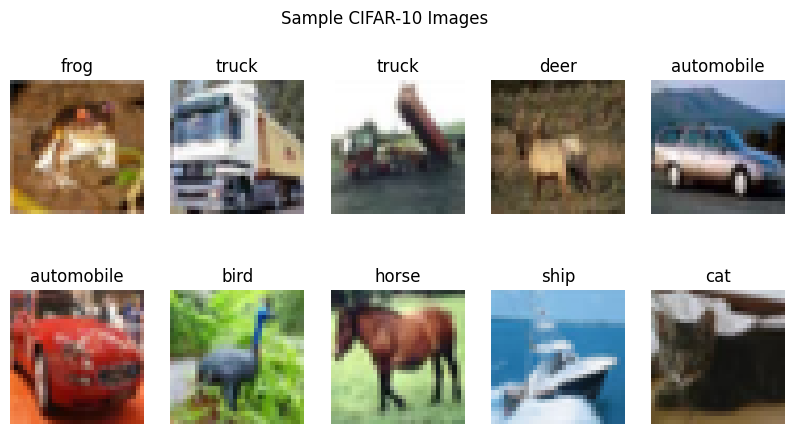

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.show()

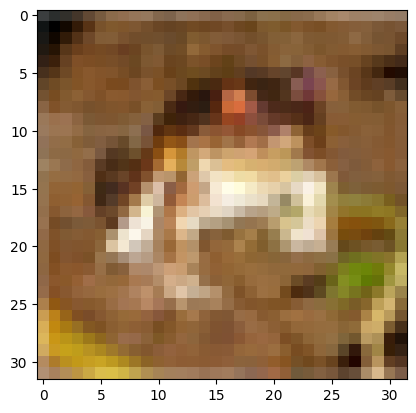

In [ ]:
plt.imshow(x_train[0])

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    #First convolutional layer
    layers.Conv2D(32, (3,3), activation='relu', padding='same', strides = (1,1), input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu',strides = (1,1), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    #2nd layer
    layers.Conv2D(64, (3,3), activation='relu',strides = (1,1), padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu',strides = (1,1), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    #flatten and dense layer
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171,178 (8.28 MB)

 Trainable params: 2,169,770 (8.28 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.4038 - loss: 1.9254 - val_accuracy: 0.2955 - val_loss: 2.4206 - learning_rate: 0.0010
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6243 - loss: 1.0566 - val_accuracy: 0.6950 - val_loss: 0.8670 - learning_rate: 0.0010
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6972 - loss: 0.8508 - val_accuracy: 0.5934 - val_loss: 1.2217 - learning_rate: 0.0010
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7364 - loss: 0.7519 - val_accuracy: 0.7360 - val_loss: 0.7559 - learning_rate: 0.0010
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7605 - loss: 0.6821 - val_accuracy: 0.7627 - val_loss: 0.6944 - learning_rate: 0.0010
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7826 - loss: 0.6169 - val_accuracy: 0.7617 - val_loss: 0.6937 - learning_rate: 0.0010
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7979 - loss: 0

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Accuracy: 80.27%


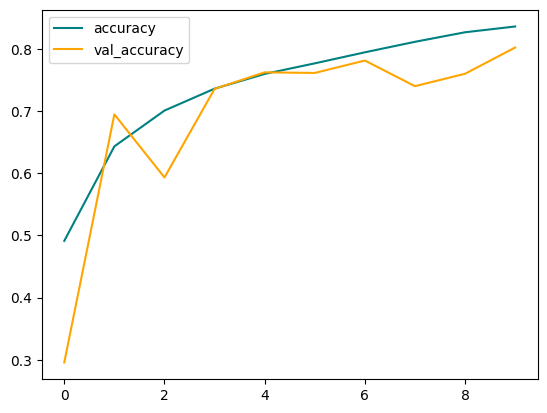

In [ ]:
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
plt.legend()
plt.show()

## Testing

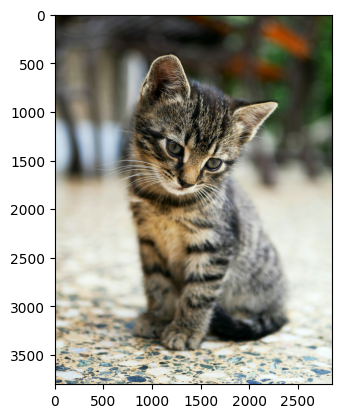

In [ ]:
import cv2
import matplotlib.pyplot as plt

test_image = cv2.imread("/content/edgar-nKC772R_qog-unsplash.jpg")
test_image_rgb = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)

plt.imshow(test_image_rgb)

In [ ]:
test_image_rgb.shape

(3803, 2853, 3)

In [ ]:
test_image_rgb = cv2.resize(test_image_rgb, (32,32))

In [ ]:
test_image_normalized = test_image_rgb / 255

In [ ]:
test_input = test_image_normalized.reshape((1,32,32,3))

In [ ]:
prediction = model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [ ]:
prediction

array([[1.6993794e-04, 1.5769435e-04, 6.2789261e-02, 4.4846341e-01,
        3.1091997e-01, 8.0900826e-03, 1.6375983e-01, 5.0582066e-03,
        4.7266926e-04, 1.1878174e-04]], dtype=float32)

In [ ]:
import numpy as np

pred = prediction
pred_index = np.argmax(pred)

print(pred_index)

3


In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(class_names[pred_index])

cat
